# 导入需要的使用的库

In [1]:
# -*- coding: utf-8 -*-
import xgboost as XGB
import pandas as pd
import numpy as np
import itertools as it
from copy import deepcopy
import math
import matplotlib.pyplot as plt
import re
import scipy.stats as st
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from lightgbm import LGBMClassifier
from imblearn.under_sampling import OneSidedSelection
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import ShuffleSplit,learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
import warnings


#显示所有列，把行显示设置成最大
# pd.set_option('display.max_columns', None)
#显示所有行，把列显示设置成最大
# pd.set_option('display.max_rows', None)

plt.rcParams['font.sans-serif'] = ['SimHei']	# 显示中文
plt.rcParams['axes.unicode_minus'] = False		# 显示负号1
warnings.filterwarnings("ignore")

# 定义提取矩阵信息的方法

In [2]:
def extract_info_matrix(df, column_id, trigger):
    """
    提取相关的矩阵
    trigger = 1: 1维
    trigger = 2: 用户效用
    trigger = 3: 服务产品对应关系
    trigger = 4: 转移矩阵and可变成本
    """
    info_dict = {}
    if trigger == 1:
        for i in range(len(df)):
            cur_all_num = [float(s) for s in re.findall(r'-?\d+\.?\d*', train_data_pd.iloc[i, column_id])]
            info_dict[i] = np.array(cur_all_num)

        return info_dict
    
    if trigger == 2:
        for i in range(len(df)):
            cur_all_num = [float(s) for s in re.findall(r'-?\d+\.?\d*', train_data_pd.iloc[i, column_id])]

            _length_customer = int(train_data_pd.iloc[i, 5])
            _length_service = int(train_data_pd.iloc[i, 6])

            current_lst = []
            lst = []

            if _length_customer == 1:
                for f in cur_all_num:
                    lst.append(f)
                current_lst.append(lst)
                info_dict[i] = current_lst
        
            else:
                for f in cur_all_num:
                    if len(lst) == _length_service and len(lst) != 0:
                        current_lst.append(lst)
                        lst = []
                    lst.append(f)
                
                current_lst.append(lst)
                current_array = np.array(current_lst)
#                 info_dict[i] = current_array.flatten()
                info_dict[i] = current_array

        return info_dict
        
    if trigger == 3:
        for i in range(len(df)):
            cur_all_num = [float(s) for s in re.findall(r'-?\d+\.?\d*', train_data_pd.iloc[i, column_id])]

            _length_product = int(train_data_pd.iloc[i, 7])
            _length_service = int(train_data_pd.iloc[i, 6])

            current_lst = []
            lst = []

            if _length_product == 1:
                for f in cur_all_num:
                    lst.append(f)
                current_lst.append(lst)
                info_dict[i] = current_lst

            else:
                for f in cur_all_num:
                    if len(lst) == _length_product and len(lst) != 0:
                        current_lst.append(lst)
                        lst = []
                    lst.append(f)

                current_lst.append(lst)
                current_array = np.array(current_lst)
#                 info_dict[i] = current_array.flatten()
                info_dict[i] = current_array

        return info_dict
        
    if trigger == 4:
        for i in range(len(df)):
            cur_all_num = [float(s) for s in re.findall(r'-?\d+\.?\d*', train_data_pd.iloc[i, column_id])]

            _length_vertex = int(train_data_pd.iloc[i, 5]) + 2

            current_lst = []
            lst = []

            if _length_vertex == 1:
                for f in cur_all_num:
                    lst.append(f)
                current_lst.append(lst)
                info_dict[i] = current_lst

            else:
                for f in cur_all_num:
                    if len(lst) == _length_vertex and len(lst) !=0:
                        current_lst.append(lst)
                        lst = []
                    lst.append(f)

                current_lst.append(lst)
                current_array = np.array(current_lst)
#                 info_dict[i] = current_array.flatten()
                info_dict[i] = current_array

        return info_dict
    
def pd_to_array(pd):
    lst_all = []
    for _index in range(len(pd)):
        lst = []
        for num in pd.iloc[_index]:
            lst.append(num)
        lst_all.append(lst)
    return lst_all

def calc_sta(data):
    new_feature = []      # median  mode/众数 偏度 峰度
    
    for key in data.keys():
        cur_data = data[key]
        cur_feature = []
        new_median = np.median(cur_data)
        new_mode = st.mode(cur_data.flatten())[0][0]
        new_skew = st.skew(cur_data.flatten(), axis=0) # 计算偏度
        new_kurtosis = st.kurtosis(cur_data.flatten()) # 计算峰度

        cur_feature.append(new_median)
        cur_feature.append(new_mode)
        cur_feature.append(new_skew)
        cur_feature.append(new_kurtosis)
        
        new_feature.append(cur_feature)
    
    return new_feature

def gen_new_feature_pd(data, name):
    feature_name = ['中位数', '众数', '偏度', '峰度']     
    column_name = [str(name) + str(i) for i in feature_name]  
    new_pd = pd.DataFrame(data, columns=column_name)          
    
    return new_pd

# 读取初始数据

In [3]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data"
result_path = data_dir / "result.csv"
derived_path = data_dir / "总数据.csv"

raw_df = pd.read_csv(result_path, dtype=str, keep_default_na=False, low_memory=False)

# 只移除真正被重复追加进去的整行表头
header_mask = raw_df.eq(pd.Series(raw_df.columns, index=raw_df.columns), axis=1).all(axis=1)
without_headers_df = raw_df.loc[~header_mask].copy()

# 去除完全重复记录
dedup_df = without_headers_df.drop_duplicates(keep="first").copy()

# 关键字段转数值
dedup_df["求解时间"] = pd.to_numeric(dedup_df["求解时间"], errors="coerce")
dedup_df["random_seed"] = pd.to_numeric(dedup_df["random_seed"], errors="coerce")
clean_numeric_df = dedup_df.dropna(subset=["求解时间", "random_seed"]).copy()

# 过滤过短求解
runtime_filtered_df = clean_numeric_df.loc[clean_numeric_df["求解时间"] > 0.5].copy()

# 当前 result.csv 中 random_seed 会跨 size_signature 重复，不能只按 random_seed 当实例键
runtime_filtered_df["instance_id"] = runtime_filtered_df[
    ["scale_phase", "scale_stage", "size_signature", "random_seed"]
].astype(str).agg("|".join, axis=1)

bundle_counts_by_instance = runtime_filtered_df["instance_id"].value_counts().sort_index()
complete_instance_ids = bundle_counts_by_instance[bundle_counts_by_instance == 64].index

train_data_pd = runtime_filtered_df.loc[
    runtime_filtered_df["instance_id"].isin(complete_instance_ids)
].copy()

# 不按真实求解时间排序，避免 top-k 评估时出现有偏的 tie-break
train_data_pd = train_data_pd.sort_values(
    ["instance_id", "有效不等式选择"]
).reset_index(drop=True)

print(f"主输入文件: {result_path}")
print(f"result.csv 原始行数: {len(raw_df)}")
print(f"清洗后样本数: {len(train_data_pd)}")
print(f"完整 64-bundle 实例数: {len(complete_instance_ids)}")


NameError: name 'Path' is not defined

In [8]:
train_data_pd['产品服务对应关系']

0        [2 1 1 2 1]
1        [2 1 1 2 1]
2        [2 1 1 2 1]
3        [2 1 1 2 1]
4        [2 1 1 2 1]
            ...     
18043    [1 1 1 1 1]
18044    [1 1 1 1 1]
18045    [1 1 1 1 1]
18046    [1 1 1 1 1]
18047    [1 1 1 1 1]
Name: 产品服务对应关系, Length: 18048, dtype: str

In [9]:
# train_data_pd=extracted_df
train_data_pd.info()

<class 'pandas.DataFrame'>
RangeIndex: 18048 entries, 0 to 18047
Data columns (total 80 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   序号                18048 non-null  str    
 1   有效不等式选择           18048 non-null  str    
 2   求解选择              18048 non-null  str    
 3   random_seed       18048 non-null  int64  
 4   gap               18048 non-null  str    
 5   scale_phase       18048 non-null  str    
 6   scale_stage       18048 non-null  str    
 7   size_signature    18048 non-null  str    
 8   客户数               18048 non-null  str    
 9   服务数               18048 non-null  str    
 10  产品数               18048 non-null  str    
 11  服务团队数             18048 non-null  str    
 12  base_num_vars     18048 non-null  str    
 13  base_num_constrs  18048 non-null  str    
 14  root_num_constrs  18048 non-null  str    
 15  服务时间              18048 non-null  str    
 16  服务价格              18048 non-null  str    
 17  服务成本

# 提取矩阵信息

In [ ]:
SerTime_matrix_dict = extract_info_matrix(train_data_pd, "服务时间", trigger=1)  # 提取服务时间向量
new_feature1 = calc_sta(SerTime_matrix_dict)
name = "服务时间"
SerTime_matrix_pd = gen_new_feature_pd(new_feature1, name)
SerTime_matrix_pd = SerTime_matrix_pd.drop(columns=["服务时间偏度"], errors="ignore")
SerTime_matrix_pd


IndexError: invalid index to scalar variable.

In [ ]:
SerPrice_matrix_dict = extract_info_matrix(train_data_pd, 10, trigger=1)  # 提取数据
new_feature2 = calc_sta(SerPrice_matrix_dict)
name = '服务价格'
SerPrice_matrix_pd = gen_new_feature_pd(new_feature2, name)
SerPrice_matrix_pd = SerPrice_matrix_pd.drop('服务价格偏度', axis=1)
SerPrice_matrix_pd

,服务价格中位数,服务价格众数,服务价格峰度
0,28.0,17.0,-1.5
1,28.0,17.0,-1.5
2,28.0,17.0,-1.5
3,28.0,17.0,-1.5
4,28.0,17.0,-1.5
...,...,...,...
4923,32.0,10.0,-1.3
4924,32.0,10.0,-1.3
4925,32.0,10.0,-1.3
4926,32.0,10.0,-1.3


In [ ]:
SerCost_matrix_dict = extract_info_matrix(train_data_pd, 11, trigger=1)  # 提取数据
new_feature3 = calc_sta(SerCost_matrix_dict)
name = '服务成本'
SerCost_matrix_pd = gen_new_feature_pd(new_feature3, name)
SerCost_matrix_pd = SerCost_matrix_pd.drop('服务成本偏度', axis=1)
SerCost_matrix_pd

,服务成本中位数,服务成本众数,服务成本峰度
0,8.0,3.0,-1.5
1,8.0,3.0,-1.5
2,8.0,3.0,-1.5
3,8.0,3.0,-1.5
4,8.0,3.0,-1.5
...,...,...,...
4923,14.0,4.0,-1.3
4924,14.0,4.0,-1.3
4925,14.0,4.0,-1.3
4926,14.0,4.0,-1.3


In [ ]:
Interest_matrix_dict = extract_info_matrix(train_data_pd, 12, trigger=1)  # 提取数据
new_feature4 = calc_sta(Interest_matrix_dict)
name = '利润'
Interest_matrix_pd = gen_new_feature_pd(new_feature4, name)
del_col = ['利润偏度', '利润峰度']
Interest_matrix_pd = Interest_matrix_pd.drop(columns=del_col, axis=1)
Interest_matrix_pd

,利润中位数,利润众数
0,20.0,14.0
1,20.0,14.0
2,20.0,14.0
3,20.0,14.0
4,20.0,14.0
...,...,...
4923,18.0,6.0
4924,18.0,6.0
4925,18.0,6.0
4926,18.0,6.0


In [ ]:
Inventory_matrix_dict = extract_info_matrix(train_data_pd, 26, trigger=1)  # 提取数据
new_feature5 = calc_sta(Inventory_matrix_dict)
name = '库存'
Inventory_matrix_pd = gen_new_feature_pd(new_feature5, name)
Inventory_matrix_pd = Inventory_matrix_pd.drop('库存偏度', axis=1)
Inventory_matrix_pd

,库存中位数,库存众数,库存峰度
0,37.0,24.0,-1.5
1,37.0,24.0,-1.5
2,37.0,24.0,-1.5
3,37.0,24.0,-1.5
4,37.0,24.0,-1.5
...,...,...,...
4923,45.0,25.0,-1.3
4924,45.0,25.0,-1.3
4925,45.0,25.0,-1.3
4926,45.0,25.0,-1.3


In [ ]:
Weight_matrix_dict = extract_info_matrix(train_data_pd, 36, trigger=1)  # 提取数据
new_feature6 = calc_sta(Weight_matrix_dict)
name = '客户权重'
Weight_matrix_pd = gen_new_feature_pd(new_feature6, name)
del_col1 = ['客户权重偏度', '客户权重峰度']
Weight_matrix_pd = Weight_matrix_pd.drop(columns=del_col1, axis=1)
Weight_matrix_pd

,客户权重中位数,客户权重众数
0,3.0,2.0
1,3.0,2.0
2,3.0,2.0
3,3.0,2.0
4,3.0,2.0
...,...,...
4923,2.0,3.0
4924,2.0,3.0
4925,2.0,3.0
4926,2.0,3.0


In [ ]:
Early_matrix_dict = extract_info_matrix(train_data_pd, 41, trigger=1)  # 提取数据
new_feature7 = calc_sta(Early_matrix_dict)
name = '时间窗下界'
Early_matrix_pd = gen_new_feature_pd(new_feature7, name)
del_col2 = ['时间窗下界偏度', '时间窗下界峰度']
Early_matrix_pd = Early_matrix_pd.drop(columns=del_col2, axis=1)
Early_matrix_pd

,时间窗下界中位数,时间窗下界众数
0,4.0,4.0
1,4.0,4.0
2,4.0,4.0
3,4.0,4.0
4,4.0,4.0
...,...,...
4923,3.0,3.0
4924,3.0,3.0
4925,3.0,3.0
4926,3.0,3.0


In [ ]:
Late_matrix_dict = extract_info_matrix(train_data_pd, 44, trigger=1)  # 提取数据
new_feature8 = calc_sta(Late_matrix_dict)
name = '时间窗上界'
Late_matrix_pd = gen_new_feature_pd(new_feature8, name)
del_col3 = ['时间窗上界偏度', '时间窗上界峰度']
Late_matrix_pd = Late_matrix_pd.drop(columns=del_col3, axis=1)
Late_matrix_pd

,时间窗上界中位数,时间窗上界众数
0,20.0,16.0
1,20.0,16.0
2,20.0,16.0
3,20.0,16.0
4,20.0,16.0
...,...,...
4923,20.0,20.0
4924,20.0,20.0
4925,20.0,20.0
4926,20.0,20.0


In [ ]:
Utility_matrix_dict = extract_info_matrix(train_data_pd, 23, trigger=2)  # 提取数据
new_feature9 = calc_sta(Utility_matrix_dict)
name = '客户效用'
Utility_matrix_pd = gen_new_feature_pd(new_feature9, name)
Utility_matrix_pd = Utility_matrix_pd.drop('客户效用偏度', axis=1)
Utility_matrix_pd

,客户效用中位数,客户效用众数,客户效用峰度
0,10.0,9.0,-1.5
1,10.0,9.0,-1.5
2,10.0,9.0,-1.5
3,10.0,9.0,-1.5
4,10.0,9.0,-1.5
...,...,...,...
4923,12.0,8.0,-1.3
4924,12.0,8.0,-1.3
4925,12.0,8.0,-1.3
4926,12.0,8.0,-1.3


In [ ]:
SP_matrix_dict = extract_info_matrix(train_data_pd, 29, trigger=3)  # 提取数据
new_feature10 = calc_sta(SP_matrix_dict)
name = '产品服务对应关系'
SP_matrix_pd = gen_new_feature_pd(new_feature10, name)
del_col4 = ['产品服务对应关系偏度', '产品服务对应关系峰度']
SP_matrix_pd = SP_matrix_pd.drop(columns=del_col4, axis=1)
# SP_matrix_pd['标准差'] = train_data_pd['产品服务对应关系'].apply(lambda x: np.std(eval(x)))
import ast

# SP_matrix_pd['标准差'] = train_data_pd['产品服务对应关系'].apply(lambda x: np.std(ast.literal_eval(x)))
SP_matrix_pd['产品服务对应关系标准差'] = train_data_pd['产品服务对应关系'].apply(lambda x: np.std(ast.literal_eval(x.replace(' ', ', '))))

SP_matrix_pd

,产品服务对应关系中位数,产品服务对应关系众数,标准差
0,1.0,1.0,0.000000
1,1.0,1.0,0.000000
2,1.0,1.0,0.000000
3,1.0,1.0,0.000000
4,1.0,1.0,0.000000
...,...,...,...
4923,1.0,1.0,0.489898
4924,1.0,1.0,0.489898
4925,1.0,1.0,0.489898
4926,1.0,1.0,0.489898


In [ ]:
Trans_matrix_dict = extract_info_matrix(train_data_pd, 53, trigger=4)  # 提取数据
new_feature11 = calc_sta(Trans_matrix_dict)
name = '转移时间矩阵'
Trans_matrix_pd = gen_new_feature_pd(new_feature11, name)
VCost_matrix_dict = extract_info_matrix(train_data_pd, 61, trigger=4)  # 提取数据
new_feature12 = calc_sta(VCost_matrix_dict)
name = '可变成本'
VCost_matrix_pd = gen_new_feature_pd(new_feature12, name)
VCost_matrix_pd = VCost_matrix_pd.drop('可变成本众数', axis=1)

In [ ]:
pac_lists1 = [
    train_data_pd,
    SerTime_matrix_pd, SerPrice_matrix_pd, SerCost_matrix_pd,
    Interest_matrix_pd, Inventory_matrix_pd, Weight_matrix_pd,
    Early_matrix_pd, Late_matrix_pd, Utility_matrix_pd,
    SP_matrix_pd, Trans_matrix_pd, VCost_matrix_pd
]
train_data_pd.reset_index(drop=True, inplace=True)
train_data_pd1 = pd.concat(pac_lists1, axis=1)
print(len(train_data_pd1))
# train_data_pd1

4928


In [ ]:
import pandas as pd
# 将字符串转换为元组
def convert_to_tuple(s):
    # 移除括号
    s = s.strip('()')
    # 分割字符串
    numbers = s.split(', ')
    # 将分割后的字符串转换为整数，并形成元组
    return tuple(map(int, numbers))


# 转换该列的每个值为元组
train_data_pd1['有效不等式选择'] = train_data_pd1['有效不等式选择'].apply(convert_to_tuple)


# 拆分这个元组为单独的列
tuple_columns = train_data_pd1['有效不等式选择'].apply(pd.Series)

# 重命名这些新列（可选）
tuple_columns.columns = ['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6']

# 将新列合并回原始DataFrame
train_data_pd1 = pd.concat([train_data_pd1, tuple_columns], axis=1)

# 可选：如果你想删除原始的元组列
train_data_pd1 = train_data_pd1.drop('有效不等式选择', axis=1)


In [ ]:
train_data_pd1

,序号,求解选择,random_seed,gap,客户数,服务数,产品数,服务团队数,服务时间,服务价格,...,转移时间矩阵峰度,可变成本中位数,可变成本偏度,可变成本峰度,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6
0,30,1,136,0,8,3,3,5,[ 6 10 14],[17 28 39],...,3.469697,1.33422,0.129844,-1.210525,0,1,1,1,1,0
1,24,1,136,0,8,3,3,5,[ 6 10 14],[17 28 39],...,3.469697,1.33422,0.129844,-1.210525,0,1,1,0,0,0
2,0,1,136,0,8,3,3,5,[ 6 10 14],[17 28 39],...,3.469697,1.33422,0.129844,-1.210525,0,0,0,0,0,0
3,6,1,136,0,8,3,3,5,[ 6 10 14],[17 28 39],...,3.469697,1.33422,0.129844,-1.210525,0,0,0,1,1,0
4,28,1,136,0,8,3,3,5,[ 6 10 14],[17 28 39],...,3.469697,1.33422,0.129844,-1.210525,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4923,5,1,9809,0,7,5,5,3,[ 4 6 8 10 12],[10 21 32 43 54],...,-0.437500,2.88031,-0.179486,-0.449303,0,0,0,1,0,1
4924,3,1,9809,0,7,5,5,3,[ 4 6 8 10 12],[10 21 32 43 54],...,-0.437500,2.88031,-0.179486,-0.449303,0,0,0,0,1,1
4925,2,1,9809,0,7,5,5,3,[ 4 6 8 10 12],[10 21 32 43 54],...,-0.437500,2.88031,-0.179486,-0.449303,0,0,0,0,1,0
4926,0,1,9809,0,7,5,5,3,[ 4 6 8 10 12],[10 21 32 43 54],...,-0.437500,2.88031,-0.179486,-0.449303,0,0,0,0,0,0


In [ ]:
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
data_dir = project_root / "data"
data_dir.mkdir(parents=True, exist_ok=True)

train_data_pd.to_csv(data_dir / "总数据.csv", index=False)

# 删除矩阵和与训练无关的列

In [ ]:
drop_columns = [
     '序号','求解选择', 'random_seed', 'gap', 
    '客户效用值', '客户效用值下界', '客户效用值梯度',
    '产品服务对应关系矩阵', '产品服务对应关系',
    '产品服务对应关系下界', '产品服务对应关系上界',
    '产品服务对应关系均值', '产品服务对应关系标准差',
    '产品服务对应关系上四分位', '总性价比', '总任务开始时间和', '总利润', '函数目标值',
    '库存', '库存梯度', '库存下界',
    '客户权重',
    '利润',
    '服务成本', '服务时间', '服务价格',
    '服务时间窗Early', '服务时间窗Late',
    '转移时间矩阵', '可变成本', '产品数',
    '服务时间梯度', '服务价格梯度', '服务成本梯度', '客户权重gap'
]

train_X_pd = train_data_pd1.drop(drop_columns, axis=1)
# 为更贴近任务目标的离线指标保留实例级元数据。
# 当前每个 random_seed 对应同一个实例下的 64 个 cut bundle。
train_meta_pd = train_data_pd1[['random_seed']].reset_index(drop=True).copy()
# # 创建新特征
# train_X_pd['排名'] = (train_X_pd.index % 64) + 1
# print(train_X_pd['排名'])
# train_X_pd.info()


In [ ]:
len(train_X_pd.columns)

76

In [ ]:
train_y_ = np.array(train_X_pd.loc[:, '求解时间'])
train_x_ = np.array(train_X_pd.drop(['求解时间'], axis=1))

train_y = train_X_pd.loc[:, '求解时间']
train_x = train_X_pd.drop(['求解时间'], axis=1)
import pandas as pd

# 假设 df 是您的原始 DataFrame
# 将所有列转换为数值类型，忽略无法转换的列
for col in train_x.columns:
    train_x[col] = pd.to_numeric(train_x[col], errors='ignore')

# 对于仍然是 object 类型的列（可能是分类数据），进行编码处理
for col in train_x.select_dtypes(include=['object']).columns:
    train_x[col] = train_x[col].astype('category').cat.codes


print(len(set(train_y_)))
print(train_x_)

4540
[['8' '3' '5' ... 1 1 0]
 ['8' '3' '5' ... 0 0 0]
 ['8' '3' '5' ... 0 0 0]
 ...
 ['7' '5' '3' ... 0 1 0]
 ['7' '5' '3' ... 0 0 0]
 ['7' '5' '3' ... 0 0 1]]


In [ ]:
train_x.columns

Index(['客户数', '服务数', '服务团队数', '利润均值', '利润标准差', '利润上四分位', '利润下四分位', '服务时间下界',
       '服务价格下界', '服务成本下界', '客户权重均值', '客户权重标准差', '客户权重上四分位', '服务时间窗Early下界',
       '服务时间窗Early上界', '服务时间窗Late下界', '服务时间窗Late上界', '服务时间窗Early均值',
       '服务时间窗Late均值', '服务时间窗Early标准差', '服务时间窗Late标准差', '服务时间窗Early上四分位',
       '服务时间窗Late上四分位', '转移时间矩阵下界', '转移时间矩阵上界', '转移时间矩阵均值', '转移时间矩阵标准差',
       '转移时间矩阵上四分位', '工作时长', '固定成本', '可变成本下界', '可变成本上界', '可变成本均值', '可变成本标准差',
       '可变成本上四分位', 'cut3百分比', '服务时间中位数', '服务时间众数', '服务时间峰度', '服务价格中位数',
       '服务价格众数', '服务价格峰度', '服务成本中位数', '服务成本众数', '服务成本峰度', '利润中位数', '利润众数',
       '库存中位数', '库存众数', '库存峰度', '客户权重中位数', '客户权重众数', '时间窗下界中位数', '时间窗下界众数',
       '时间窗上界中位数', '时间窗上界众数', '客户效用中位数', '客户效用众数', '客户效用峰度', '产品服务对应关系中位数',
       '产品服务对应关系众数', '标准差', '转移时间矩阵中位数', '转移时间矩阵众数', '转移时间矩阵偏度', '转移时间矩阵峰度',
       '可变成本中位数', '可变成本偏度', '可变成本峰度', 'Feature1', 'Feature2', 'Feature3',
       'Feature4', 'Feature5', 'Feature6'],
      dtype='object')

# 不做任何处理进行训练

In [ ]:
seed = 7
test_size = 0.33
X_train1, X_test1, y_train1, y_test1 = train_test_split(train_x, train_y, test_size=test_size, random_state=seed)
# X_train1=train_x_[:3521]
# X_test1=train_x_[3521:]
# y_train1=train_y_[:3521]
# y_test1=train_y_[3521:]
from lightgbm import LGBMRegressor
from sklearn.model_selection import GroupShuffleSplit
# 这里值得关注
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

def make_lgbm_regressor():
    return LGBMRegressor(
        colsample_bytree=0.7,
        learning_rate=0.2,
        max_depth=3,
        n_estimators=200,
        n_jobs=-1,
        random_state=0,
        subsample=0.85,
        reg_alpha=0,
        reg_lambda=0.01
    )

def summarize_regression_metrics(y_true, y_pred, prefix=''):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        f'{prefix}mse': mse,
        f'{prefix}rmse': rmse,
        f'{prefix}mae': mae,
        f'{prefix}r2': r2,
    }

def summarize_task_metrics(eval_df, group_col='random_seed', topk=(1, 3, 5)):
    per_instance_rows = []
    for instance_id, g in eval_df.groupby(group_col):
        g = g.copy()
        if len(g) < 2:
            continue
        true_best_idx = g['true_runtime'].idxmin()
        pred_best_idx = g['pred_runtime'].idxmin()
        row = {
            'random_seed': instance_id,
            'bundle_count': len(g),
            'true_best_runtime': float(g.loc[true_best_idx, 'true_runtime']),
            'pred_selected_runtime': float(g.loc[pred_best_idx, 'true_runtime']),
            'regret': float(g.loc[pred_best_idx, 'true_runtime'] - g.loc[true_best_idx, 'true_runtime']),
            'top1_hit': int(pred_best_idx == true_best_idx),
        }
        rho = spearmanr(g['true_runtime'], g['pred_runtime']).correlation
        row['spearman'] = np.nan if pd.isna(rho) else float(rho)
        pred_ranked = g.nsmallest(len(g), 'pred_runtime')
        for k in topk:
            pred_topk_idx = set(pred_ranked.head(min(k, len(g))).index)
            row[f'top{k}_hit'] = int(true_best_idx in pred_topk_idx)
        per_instance_rows.append(row)

    task_case_df = pd.DataFrame(per_instance_rows)
    if task_case_df.empty:
        return task_case_df, pd.DataFrame([{
            'instance_count': 0,
            'avg_spearman': np.nan,
            'top1_hit_rate': np.nan,
            'top3_hit_rate': np.nan,
            'top5_hit_rate': np.nan,
            'mean_regret': np.nan,
            'median_regret': np.nan,
            'max_regret': np.nan,
        }])

    task_summary_df = pd.DataFrame([{
        'instance_count': int(len(task_case_df)),
        'avg_spearman': task_case_df['spearman'].dropna().mean(),
        'top1_hit_rate': task_case_df['top1_hit'].mean(),
        'top3_hit_rate': task_case_df['top3_hit'].mean() if 'top3_hit' in task_case_df.columns else np.nan,
        'top5_hit_rate': task_case_df['top5_hit'].mean() if 'top5_hit' in task_case_df.columns else np.nan,
        'mean_regret': task_case_df['regret'].mean(),
        'median_regret': task_case_df['regret'].median(),
        'max_regret': task_case_df['regret'].max(),
    }])
    return task_case_df, task_summary_df

def evaluate_grouped_holdout(model_builder, X_df, y_series, meta_df, group_col='random_seed', test_size=0.33, random_state=7):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X_df, y_series, groups=meta_df[group_col]))
    model = model_builder()
    model.fit(X_df.iloc[train_idx], y_series.iloc[train_idx])

    train_pred = model.predict(X_df.iloc[train_idx])
    test_pred = model.predict(X_df.iloc[test_idx])

    regression_summary = {
        **summarize_regression_metrics(y_series.iloc[train_idx], train_pred, prefix='train_'),
        **summarize_regression_metrics(y_series.iloc[test_idx], test_pred, prefix='test_'),
    }

    eval_df = meta_df.iloc[test_idx].reset_index(drop=True).copy()
    eval_df['true_runtime'] = y_series.iloc[test_idx].reset_index(drop=True)
    eval_df['pred_runtime'] = pd.Series(test_pred)
    task_case_df, task_summary_df = summarize_task_metrics(eval_df, group_col=group_col)
    return model, regression_summary, task_case_df, task_summary_df, train_idx, test_idx

gbm1 = make_lgbm_regressor()
gbm1.fit(X_train1, y_train1)

gbm_train_pred = gbm1.predict(X_train1)
gbm_test_pred = gbm1.predict(X_test1)
baseline_split_summary_df = pd.DataFrame([{
    **summarize_regression_metrics(y_train1, gbm_train_pred, prefix='train_'),
    **summarize_regression_metrics(y_test1, gbm_test_pred, prefix='test_'),
}])
print('样本级随机切分 LightGBM 基线指标:')
display(baseline_split_summary_df)

gbm1_group, baseline_group_regression, baseline_group_case_df, baseline_group_task_df, group_train_idx, group_test_idx = evaluate_grouped_holdout(
    make_lgbm_regressor,
    train_x.reset_index(drop=True),
    train_y.reset_index(drop=True),
    train_meta_pd,
    test_size=test_size,
    random_state=seed,
)
print('实例级分组留出 LightGBM 回归指标:')
display(pd.DataFrame([baseline_group_regression]))
print('实例级分组留出 LightGBM 任务指标:')
display(baseline_group_task_df)

def build_importance_df(model, feature_names):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'split_importance': model.booster_.feature_importance(importance_type='split'),
        'gain_importance': model.booster_.feature_importance(importance_type='gain')
    })
    importance_df['split_rank'] = importance_df['split_importance'].rank(method='dense', ascending=False)
    importance_df['gain_rank'] = importance_df['gain_importance'].rank(method='dense', ascending=False)
    return importance_df.sort_values(by='gain_importance', ascending=False).reset_index(drop=True)

raw_importance_df = build_importance_df(gbm1, train_x.columns)
raw_importance_df.head(20)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 3301, number of used features: 74
[LightGBM] [Info] Start training from score 22.850221
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
model =  LGBMRegressor(
    colsample_bytree=0.7,
    learning_rate=0.2,
    max_depth=3,
    n_estimators=200,
    n_jobs=-1,  # 'nthread' 在新版本中改为 'n_jobs'
    random_state=0,  # 'seed' 在新版本中改为 'random_state'
    subsample=0.85,
    reg_alpha=0,  # L1 regularization
    reg_lambda=0.01  # L2 regularization, 'lambda_l2' 改为 'reg_lambda'
    # 其他对回归任务有意义的参数
)
mse_scores = -cross_val_score(model, train_x_, train_y_, cv=kfold, scoring='accuracy')
print("十折交叉验证下线性回归模型平均MSE值: {:.2f} (+/- {:.2f})".format(mse_scores.mean(),
                                                        mse_scores.std()))
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
for i, (train_idx, test_idx) in enumerate(kfold.split(train_x_)):
    model.fit(train_x_[train_idx], train_y_[train_idx])
    print("第{}次测试 R^2 值: {:.2f}".format(i+1, model.score(train_x_[test_idx], train_y_[test_idx])))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1903
[LightGBM] [Info] Number of data points in the train set: 4435, number of used features: 74
[LightGBM] [Info] Start training from score 23.143623
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
train_y.value_counts(normalize=True), len(train_y)

(0     0.132616
 7     0.086022
 4     0.086022
 5     0.075269
 1     0.064516
 3     0.053763
 6     0.039427
 2     0.035842
 47    0.025090
 62    0.021505
 12    0.021505
 37    0.017921
 55    0.017921
 60    0.017921
 28    0.014337
 24    0.014337
 43    0.014337
 27    0.014337
 13    0.014337
 15    0.014337
 44    0.010753
 61    0.010753
 18    0.010753
 57    0.010753
 40    0.010753
 45    0.007168
 46    0.007168
 31    0.007168
 17    0.007168
 23    0.007168
 53    0.007168
 32    0.007168
 48    0.007168
 10    0.007168
 33    0.007168
 56    0.007168
 50    0.007168
 59    0.007168
 22    0.007168
 25    0.007168
 11    0.007168
 29    0.003584
 52    0.003584
 42    0.003584
 30    0.003584
 21    0.003584
 63    0.003584
 14    0.003584
 19    0.003584
 26    0.003584
 34    0.003584
 8     0.003584
 36    0.003584
 54    0.003584
 49    0.003584
 Name: 序号, dtype: float64,
 279)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 初始化XGBoost回归模型
xgb_reg = XGBRegressor(
    colsample_bytree=0.7, 
    lambda_l2=0.01, 
    learning_rate=0.01, 
    max_depth=5, 
    min_child_weight=2, 
    n_estimators=200,
    objective='reg:squarederror'  # 设置为回归任务的目标函数
)

# 训练模型
xgb_reg.fit(X_train1, y_train1)

# 使用均方误差(MSE)和决定系数(R²)评估模型性能
mse_test = mean_squared_error(y_test1, xgb_reg.predict(X_test1))
mse_train = mean_squared_error(y_train1, xgb_reg.predict(X_train1))
r2_test = r2_score(y_test1, xgb_reg.predict(X_test1))
r2_train = r2_score(y_train1, xgb_reg.predict(X_train1))

mse_test, mse_train, r2_test, r2_train

(707.4830911602501, 362.03890601950883, 0.8490374519278516, 0.9060650852879946)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# # 用列的均值填充NaN
# imputer = SimpleImputer(strategy='mean')
# X_train1 = imputer.fit_transform(X_train1)
# X_test1 = imputer.transform(X_test1) 

# 初始化随机森林回归器
rf = RandomForestRegressor(n_estimators=200, random_state=seed)

# 训练模型
rf.fit(X_train1, y_train1)

# 计算测试集和训练集的MSE和R²
mse_test = mean_squared_error(y_test1, rf.predict(X_test1))
mse_train = mean_squared_error(y_train1, rf.predict(X_train1))
r2_test = r2_score(y_test1, rf.predict(X_test1))
r2_train = r2_score(y_train1, rf.predict(X_train1))

mse_test, mse_train, r2_test, r2_train

(42.6131356699622, 3.730938272088994, 0.9909072207909142, 0.9990319676627087)

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
for i, (train_idx, test_idx) in enumerate(kfold.split(train_x_)):
    rf.fit(train_x_[train_idx], train_y_[train_idx])
    print("第{}次测试 R^2 值: {:.4f}".format(i+1, rf.score(train_x_[test_idx], train_y_[test_idx])))

第1次测试 R^2 值: 0.9995
第2次测试 R^2 值: 0.9996
第3次测试 R^2 值: 0.9993
第4次测试 R^2 值: 0.9989
第5次测试 R^2 值: 0.9991
第6次测试 R^2 值: 0.9990
第7次测试 R^2 值: 0.9992
第8次测试 R^2 值: 0.9987
第9次测试 R^2 值: 0.9977
第10次测试 R^2 值: 0.9992


In [ ]:
print(rf.predict(X_test1))
print(y_test1)

[  1.34237601   2.17466501 157.09656007 ...   2.66353003 213.46105011
 446.21350717]
3492      1.354000
1430      2.052000
3032    157.377000
3043    181.546000
145      24.046000
           ...    
3838      2.952000
4471      2.572000
3852      2.654000
3058    213.024000
300     445.547369
Name: 求解时间, Length: 1627, dtype: float64


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 初始化GBDT回归模型
gbdt_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)

# 训练模型
gbdt_reg.fit(X_train1, y_train1)

# 评估模型性能
gbdt_mse_test = mean_squared_error(y_test1, gbdt_reg.predict(X_test1))
gbdt_mse_train = mean_squared_error(y_train1, gbdt_reg.predict(X_train1))
gbdt_r2_test = r2_score(y_test1, gbdt_reg.predict(X_test1))
gbdt_r2_train = r2_score(y_train1, gbdt_reg.predict(X_train1))
gbdt_mse_test,gbdt_mse_train,gbdt_r2_test,gbdt_r2_train

(19.64800291306586, 7.510425284884429, 0.9958075145238863, 0.9980513388289034)

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
for i, (train_idx, test_idx) in enumerate(kfold.split(train_x_)):
    gbdt_reg.fit(train_x_[train_idx], train_y_[train_idx])
    print("第{}次测试 R^2 值: {:.4f}".format(i+1, gbdt_reg.score(train_x_[test_idx], train_y_[test_idx])))

第1次测试 R^2 值: 0.9962
第2次测试 R^2 值: 0.9977
第3次测试 R^2 值: 0.9969
第4次测试 R^2 值: 0.9982
第5次测试 R^2 值: 0.9978
第6次测试 R^2 值: 0.9978
第7次测试 R^2 值: 0.9968
第8次测试 R^2 值: 0.9962
第9次测试 R^2 值: 0.9974
第10次测试 R^2 值: 0.9979


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# # 用列的均值填充NaN
# imputer = SimpleImputer(strategy='mean')
# X_train1 = imputer.fit_transform(X_train1)
# X_test1 = imputer.transform(X_test1)

# 特征标准化
scaler = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)

# 初始化支持向量机回归器
svm_reg = SVR()

# 训练模型
svm_reg.fit(X_train1_scaled, y_train1)

# 使用均方误差(MSE)和决定系数(R²)评估模型性能
mse_test = mean_squared_error(y_test1, svm_reg.predict(X_test1_scaled))
mse_train = mean_squared_error(y_train1, svm_reg.predict(X_train1_scaled))
r2_test = r2_score(y_test1, svm_reg.predict(X_test1_scaled))
r2_train = r2_score(y_train1, svm_reg.predict(X_train1_scaled))

# 输出结果
mse_test, mse_train, r2_test, r2_train

(4115.40102981457,
 3273.8903957572556,
 0.12185685628092513,
 0.15055368362719568)

In [ ]:
from sklearn.linear_model import LinearRegression

# 初始化线性回归模型
lr = LinearRegression()

# 训练模型
lr.fit(X_train1, y_train1)

# 评估模型性能
lr_mse_test = mean_squared_error(y_test1, lr.predict(X_test1))
lr_mse_train = mean_squared_error(y_train1, lr.predict(X_train1))
lr_r2_test = r2_score(y_test1, lr.predict(X_test1))
lr_r2_train = r2_score(y_train1, lr.predict(X_train1))
lr_mse_test,lr_mse_train,lr_r2_test,lr_r2_train

(2125.5490823560485,
 1438.2656752279279,
 0.5464509194153949,
 0.6268263954801029)

# 特征选择
## LightGBM importance
### 评分小于等于155

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

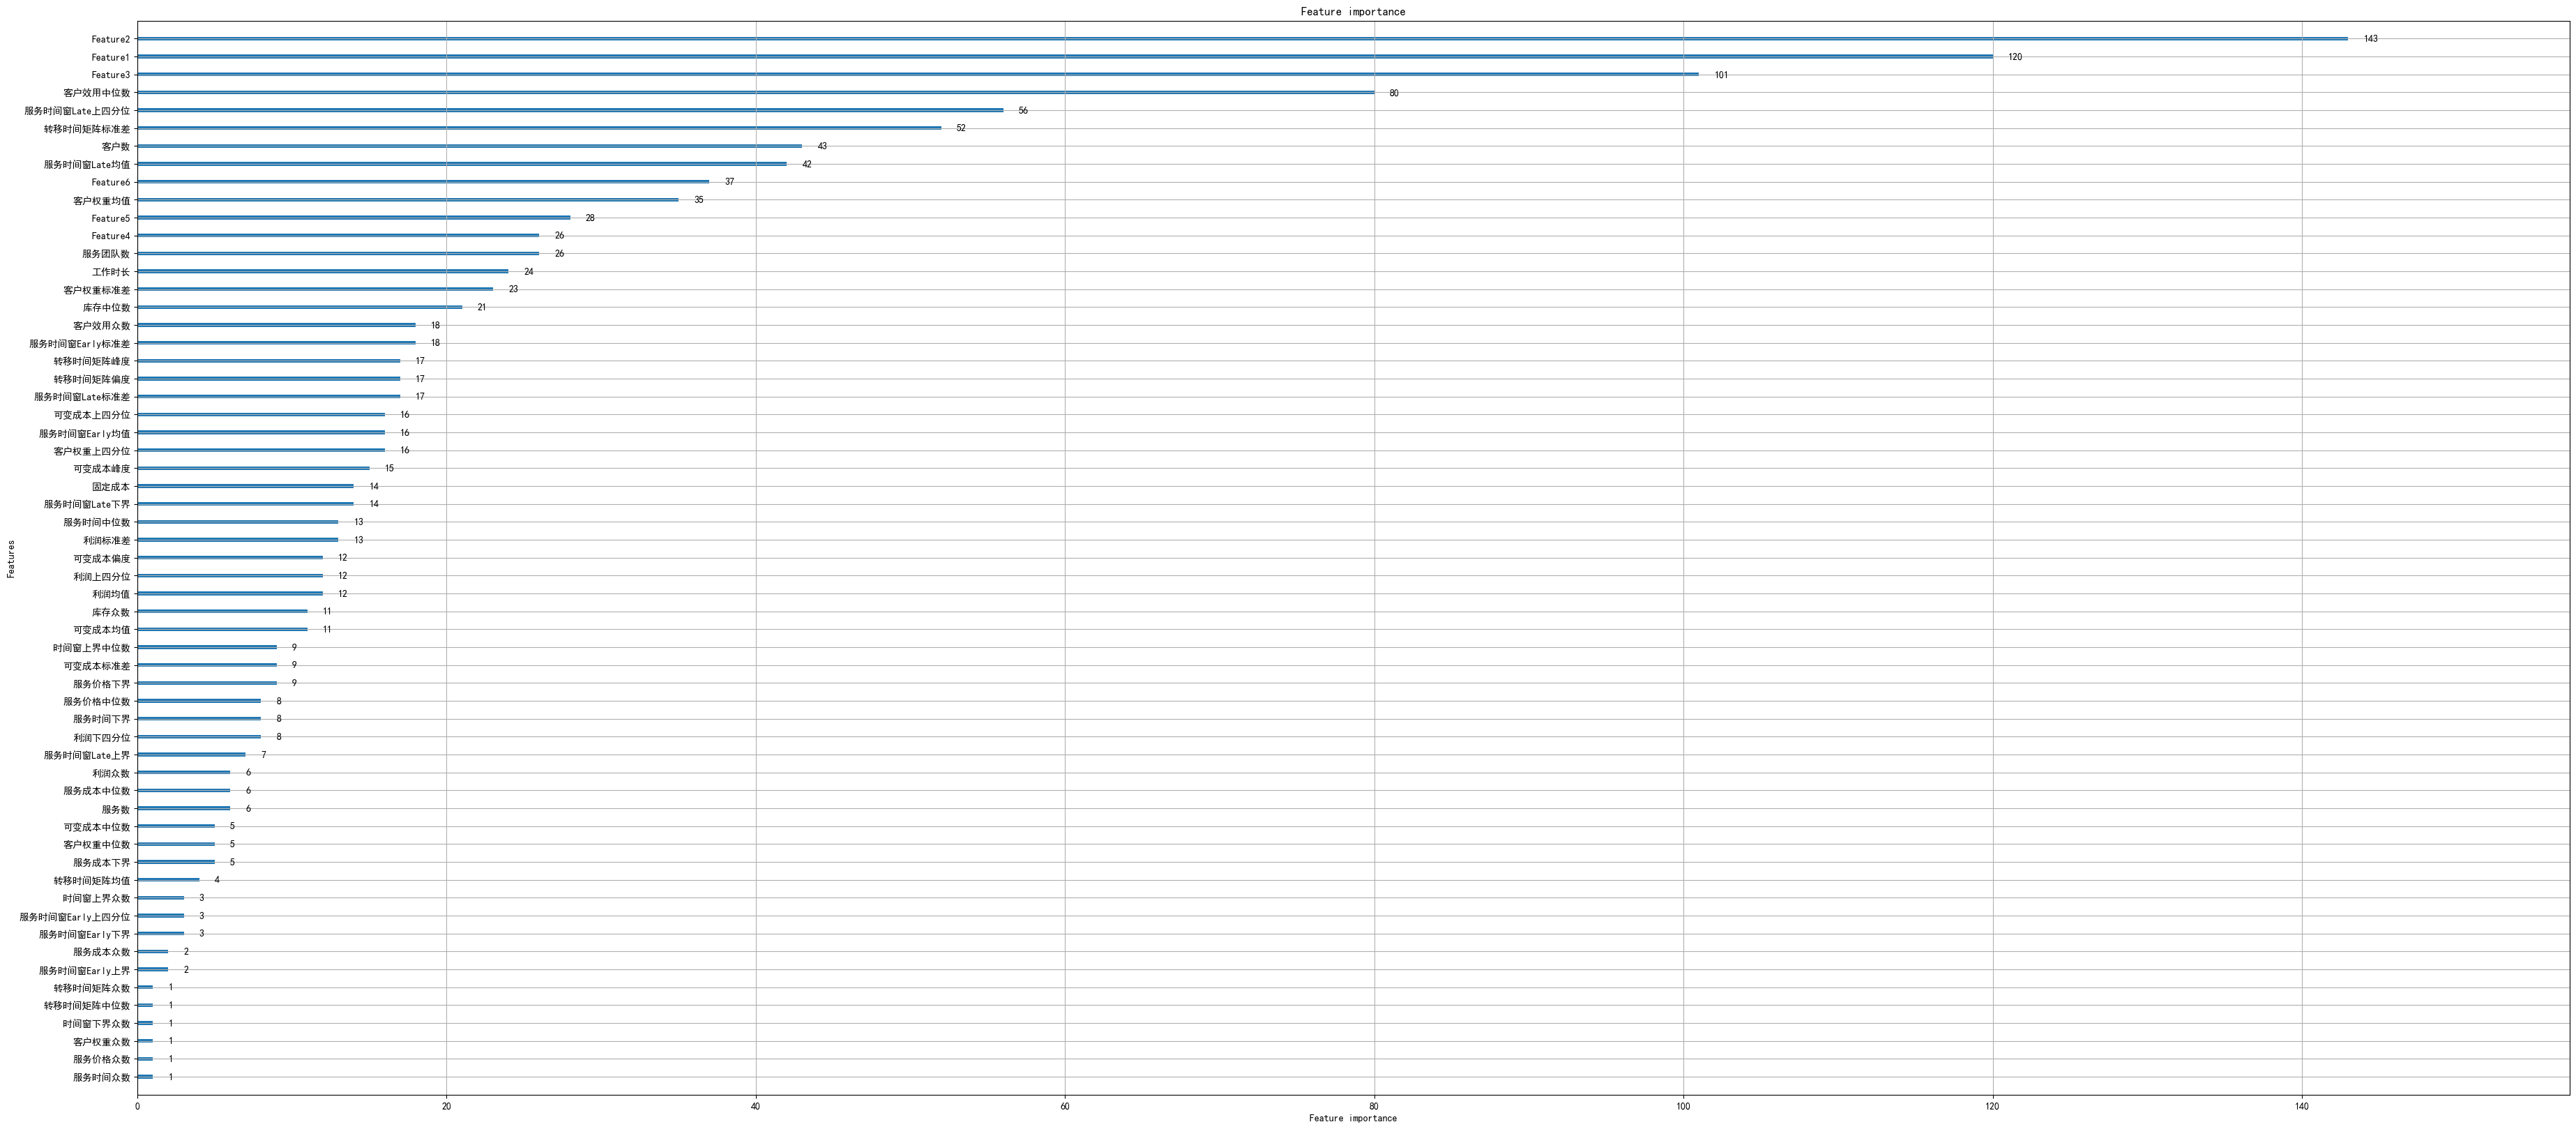

In [ ]:
from lightgbm import plot_importance
print('原始特征集 split importance')
plot_importance(gbm1, importance_type='split', figsize=(45, 20), max_num_features=30)
plt.show()

print('原始特征集 gain importance')
plot_importance(gbm1, importance_type='gain', figsize=(45, 20), max_num_features=30)
plt.show()

split_top_features = raw_importance_df.sort_values(by='split_importance', ascending=False)[['feature', 'split_importance', 'gain_importance']].head(15)
gain_top_features = raw_importance_df.sort_values(by='gain_importance', ascending=False)[['feature', 'gain_importance', 'split_importance']].head(15)
split_top_set = set(split_top_features['feature'])
gain_top_set = set(gain_top_features['feature'])
print('split/gain Top15 重合特征数:', len(split_top_set & gain_top_set))
print('仅出现在 split Top15 的特征:', sorted(split_top_set - gain_top_set))
print('仅出现在 gain Top15 的特征:', sorted(gain_top_set - split_top_set))
display(split_top_features)
display(gain_top_features)
display(raw_importance_df.head(20))

In [ ]:
# gmb_unim = [
#    'cut3百分比', '服务时间下界', '服务成本峰度',
#     '服务价格下界', '转移时间矩阵中位数', '转移时间矩阵上界',
#     '可变成本上界', '客户权重gap', '利润中位数',
#     '服务成本下界', '服务价格峰度', '服务时间窗Early上界',
#     '可变成本下界', '利润均值','利润上四分位', '利润下四分位', '利润中位数', '服务价格中位数',
#     '服务时间下界', '服务价格下界', '服务成本下界', '客户权重上四分位',
#     '客户权重中位数', '服务时间窗Late上界', '服务时间窗Early均值',
#     '服务时间窗Late上四分位', '时间窗上界中位数', '服务时间窗Early上四分位',
#     '转移时间矩阵上界', '转移时间矩阵上四分位', '转移时间矩阵中位数',
#     '可变成本上四分位', '可变成本中位数', '可变成本上四分位', '服务时间峰度'
# ]
gmb_unim_split = ['cut3百分比','服务时间窗Early上界','转移时间矩阵下界','客户权重众数',
                  '服务数','服务价格下界','服务时间窗Late上界','利润众数','服务时间窗Late下界','时间窗下界众数','时间窗上界中位数',
                  '服务时间窗Early上四分位','转移时间矩阵均值','固定成本','客户权重中位数','可变成本中位数','服务成本下界',
                  '库存众数','利润下四分位','服务价格中位数','服务成本中位数','转移时间矩阵峰度','求解时间','服务时间窗Early标准差',
                 '客户效用众数']

# 根据 gain importance 图和 importance 对照表手工填写要删除的特征。
# 默认先不删除，便于和 split-based 路径做并行对比。
gmb_unim_gain = []

gmb_unim = gmb_unim_split.copy()
train_y_sm=np.array(train_y)

# split importance 人工删列路径（保留原变量名，兼容后续单元）
train_x_drop_gbm_pd = train_X_pd.drop(gmb_unim,axis = 1)
train_x_drop_gmb = np.array(train_x_drop_gbm_pd)
X_train_drop_uni, X_test_drop_uni, y_train_drop_uni, y_test_drop_uni = train_test_split(train_x_drop_gmb, train_y_sm, test_size=test_size, random_state=seed)

gbm_drop_uni = make_lgbm_regressor()
gbm_drop_uni.fit(X_train_drop_uni,y_train_drop_uni)

split_drop_train_pred = gbm_drop_uni.predict(X_train_drop_uni)
split_drop_test_pred = gbm_drop_uni.predict(X_test_drop_uni)
split_drop_summary_df = pd.DataFrame([{
    **summarize_regression_metrics(y_train_drop_uni, split_drop_train_pred, prefix='train_'),
    **summarize_regression_metrics(y_test_drop_uni, split_drop_test_pred, prefix='test_'),
}])
print('split-based 删列结果（样本级随机切分）:')
display(split_drop_summary_df)

gbm_drop_uni_group, split_group_regression, split_group_case_df, split_group_task_df, split_group_train_idx, split_group_test_idx = evaluate_grouped_holdout(
    make_lgbm_regressor,
    train_x_drop_gbm_pd.reset_index(drop=True),
    train_y.reset_index(drop=True),
    train_meta_pd,
    test_size=test_size,
    random_state=seed,
)
print('split-based 删列结果（实例级分组留出）的回归指标:')
display(pd.DataFrame([split_group_regression]))
print('split-based 删列结果（实例级分组留出）的任务指标:')
display(split_group_task_df)

# gain importance 人工删列路径
train_x_drop_gain_pd = train_X_pd.drop(gmb_unim_gain, axis=1)
train_x_drop_gain = np.array(train_x_drop_gain_pd)
X_train_drop_gain, X_test_drop_gain, y_train_drop_gain, y_test_drop_gain = train_test_split(train_x_drop_gain, train_y_sm, test_size=test_size, random_state=seed)

gbm_drop_gain = make_lgbm_regressor()
gbm_drop_gain.fit(X_train_drop_gain, y_train_drop_gain)

gain_drop_train_pred = gbm_drop_gain.predict(X_train_drop_gain)
gain_drop_test_pred = gbm_drop_gain.predict(X_test_drop_gain)
gain_drop_summary_df = pd.DataFrame([{
    **summarize_regression_metrics(y_train_drop_gain, gain_drop_train_pred, prefix='train_'),
    **summarize_regression_metrics(y_test_drop_gain, gain_drop_test_pred, prefix='test_'),
}])
print('gain-based 删列结果（样本级随机切分）:')
display(gain_drop_summary_df)

gbm_drop_gain_group, gain_group_regression, gain_group_case_df, gain_group_task_df, gain_group_train_idx, gain_group_test_idx = evaluate_grouped_holdout(
    make_lgbm_regressor,
    train_x_drop_gain_pd.reset_index(drop=True),
    train_y.reset_index(drop=True),
    train_meta_pd,
    test_size=test_size,
    random_state=seed,
)
print('gain-based 删列结果（实例级分组留出）的回归指标:')
display(pd.DataFrame([gain_group_regression]))
print('gain-based 删列结果（实例级分组留出）的任务指标:')
display(gain_group_task_df)

selection_compare_df = pd.DataFrame([
    {
        'scheme': 'split_manual',
        'removed_feature_count': len(gmb_unim_split),
        'sample_test_mse': split_drop_summary_df.loc[0, 'test_mse'],
        'sample_test_rmse': split_drop_summary_df.loc[0, 'test_rmse'],
        'sample_test_mae': split_drop_summary_df.loc[0, 'test_mae'],
        'sample_test_r2': split_drop_summary_df.loc[0, 'test_r2'],
        'group_test_mse': split_group_regression['test_mse'],
        'group_test_rmse': split_group_regression['test_rmse'],
        'group_test_mae': split_group_regression['test_mae'],
        'group_test_r2': split_group_regression['test_r2'],
        'avg_spearman': split_group_task_df.loc[0, 'avg_spearman'],
        'top1_hit_rate': split_group_task_df.loc[0, 'top1_hit_rate'],
        'top3_hit_rate': split_group_task_df.loc[0, 'top3_hit_rate'],
        'top5_hit_rate': split_group_task_df.loc[0, 'top5_hit_rate'],
        'mean_regret': split_group_task_df.loc[0, 'mean_regret'],
        'median_regret': split_group_task_df.loc[0, 'median_regret'],
    },
    {
        'scheme': 'gain_manual',
        'removed_feature_count': len(gmb_unim_gain),
        'sample_test_mse': gain_drop_summary_df.loc[0, 'test_mse'],
        'sample_test_rmse': gain_drop_summary_df.loc[0, 'test_rmse'],
        'sample_test_mae': gain_drop_summary_df.loc[0, 'test_mae'],
        'sample_test_r2': gain_drop_summary_df.loc[0, 'test_r2'],
        'group_test_mse': gain_group_regression['test_mse'],
        'group_test_rmse': gain_group_regression['test_rmse'],
        'group_test_mae': gain_group_regression['test_mae'],
        'group_test_r2': gain_group_regression['test_r2'],
        'avg_spearman': gain_group_task_df.loc[0, 'avg_spearman'],
        'top1_hit_rate': gain_group_task_df.loc[0, 'top1_hit_rate'],
        'top3_hit_rate': gain_group_task_df.loc[0, 'top3_hit_rate'],
        'top5_hit_rate': gain_group_task_df.loc[0, 'top5_hit_rate'],
        'mean_regret': gain_group_task_df.loc[0, 'mean_regret'],
        'median_regret': gain_group_task_df.loc[0, 'median_regret'],
    }
])
selection_compare_df


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1320
[LightGBM] [Info] Number of data points in the train set: 3301, number of used features: 49
[LightGBM] [Info] Start training from score 22.850221
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
# 初始化XGBoost回归模型
xgb_reg = XGBRegressor(
    colsample_bytree=0.7, 
    lambda_l2=0.01, 
    learning_rate=0.01, 
    max_depth=5, 
    min_child_weight=2, 
    n_estimators=200,
    objective='reg:squarederror'  # 设置为回归任务的目标函数
)

# 训练模型
xgb_reg.fit(X_train_drop_uni,y_train_drop_uni)

# 使用均方误差(MSE)和决定系数(R²)评估模型性能
mse_test = mean_squared_error(y_test_drop_uni, xgb_reg.predict(X_test_drop_uni))
mse_train = mean_squared_error(y_train_drop_uni,xgb_reg.predict(X_train_drop_uni))
print(mse_train,mse_test)
r2_test =r2_score(y_test_drop_uni, xgb_reg.predict(X_test_drop_uni))
r2_train=r2_score(y_train_drop_uni, xgb_reg.predict(X_train_drop_uni))
print(r2_test,r2_train)

355.68828729451565 688.9869431574352
0.8529841549189371 0.907712822087499


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# # 用列的均值填充NaN
# imputer = SimpleImputer(strategy='mean')
# X_train1 = imputer.fit_transform(X_train_drop_uni)
# X_test1 = imputer.transform(X_test_drop_uni) 

# 初始化随机森林回归器
rf = RandomForestRegressor(n_estimators=200, random_state=seed)

# 训练模型
rf.fit(X_train1, y_train1)

# 计算测试集和训练集的MSE和R²
mse_test = mean_squared_error(y_test1, rf.predict(X_test1))
mse_train = mean_squared_error(y_train1, rf.predict(X_train1))
r2_test = r2_score(y_test1, rf.predict(X_test1))
r2_train = r2_score(y_train1, rf.predict(X_train1))

mse_test, mse_train, r2_test, r2_train

(42.6131356699622, 3.730938272088994, 0.9909072207909142, 0.9990319676627087)

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
for i, (train_idx, test_idx) in enumerate(kfold.split(train_x_drop_gmb)):
    rf.fit(train_x_drop_gmb[train_idx], train_y_sm[train_idx])
    print("第{}次测试 R^2 值: {:.4f}".format(i+1, rf.score(train_x_drop_gmb[test_idx], train_y_sm[test_idx])))

第1次测试 R^2 值: 0.9994
第2次测试 R^2 值: 0.9996
第3次测试 R^2 值: 0.9993
第4次测试 R^2 值: 0.9989
第5次测试 R^2 值: 0.9992
第6次测试 R^2 值: 0.9990
第7次测试 R^2 值: 0.9992
第8次测试 R^2 值: 0.9986
第9次测试 R^2 值: 0.9977
第10次测试 R^2 值: 0.9992


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 初始化GBDT回归模型
gbdt_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)

# 训练模型
gbdt_reg.fit(X_train1, y_train1)

# 评估模型性能
gbdt_mse_test = mean_squared_error(y_test1, gbdt_reg.predict(X_test1))
gbdt_mse_train = mean_squared_error(y_train1, gbdt_reg.predict(X_train1))
gbdt_r2_test = r2_score(y_test1, gbdt_reg.predict(X_test1))
gbdt_r2_train = r2_score(y_train1, gbdt_reg.predict(X_train1))
gbdt_mse_test,gbdt_mse_train,gbdt_r2_test,gbdt_r2_train

(19.700462204698177, 7.51042528488443, 0.9957963207746168, 0.9980513388289034)

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=7)
for i, (train_idx, test_idx) in enumerate(kfold.split(train_x_drop_gmb)):
    gbdt_reg.fit(train_x_drop_gmb[train_idx], train_y_sm[train_idx])
    print("第{}次测试 R^2 值: {:.4f}".format(i+1, gbdt_reg.score(train_x_drop_gmb[test_idx], train_y_sm[test_idx])))

第1次测试 R^2 值: 0.9970
第2次测试 R^2 值: 0.9980
第3次测试 R^2 值: 0.9971
第4次测试 R^2 值: 0.9978
第5次测试 R^2 值: 0.9970
第6次测试 R^2 值: 0.9962
第7次测试 R^2 值: 0.9968
第8次测试 R^2 值: 0.9967
第9次测试 R^2 值: 0.9975
第10次测试 R^2 值: 0.9965


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# 特征标准化
scaler = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)

# 初始化支持向量机回归器
svm_reg = SVR()

# 训练模型
svm_reg.fit(X_train1_scaled, y_train1)

# 使用均方误差(MSE)和决定系数(R²)评估模型性能
mse_test = mean_squared_error(y_test1, svm_reg.predict(X_test1_scaled))
mse_train = mean_squared_error(y_train1, svm_reg.predict(X_train1_scaled))
r2_test = r2_score(y_test1, svm_reg.predict(X_test1_scaled))
r2_train = r2_score(y_train1, svm_reg.predict(X_train1_scaled))

# 输出结果
mse_test, mse_train, r2_test, r2_train

(4115.40102981457,
 3273.8903957572556,
 0.12185685628092513,
 0.15055368362719568)

In [ ]:
from sklearn.linear_model import LinearRegression

# 初始化线性回归模型
lr = LinearRegression()

lr.fit(X_train1, train_y_sm[train_idx])
print("第{}次测试 R^2 值: {:.2f}".format(i+1, lr.score(X_test1, train_y_sm[test_idx])))

第1次测试 R^2 值: 0.41
第2次测试 R^2 值: 0.36
第3次测试 R^2 值: 0.57
第4次测试 R^2 值: 0.49
第5次测试 R^2 值: 0.57
第6次测试 R^2 值: 0.53
第7次测试 R^2 值: 0.55
第8次测试 R^2 值: 0.58
第9次测试 R^2 值: 0.47
第10次测试 R^2 值: 0.45


In [ ]:
len(train_x_drop_gbm_pd.columns)

50

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

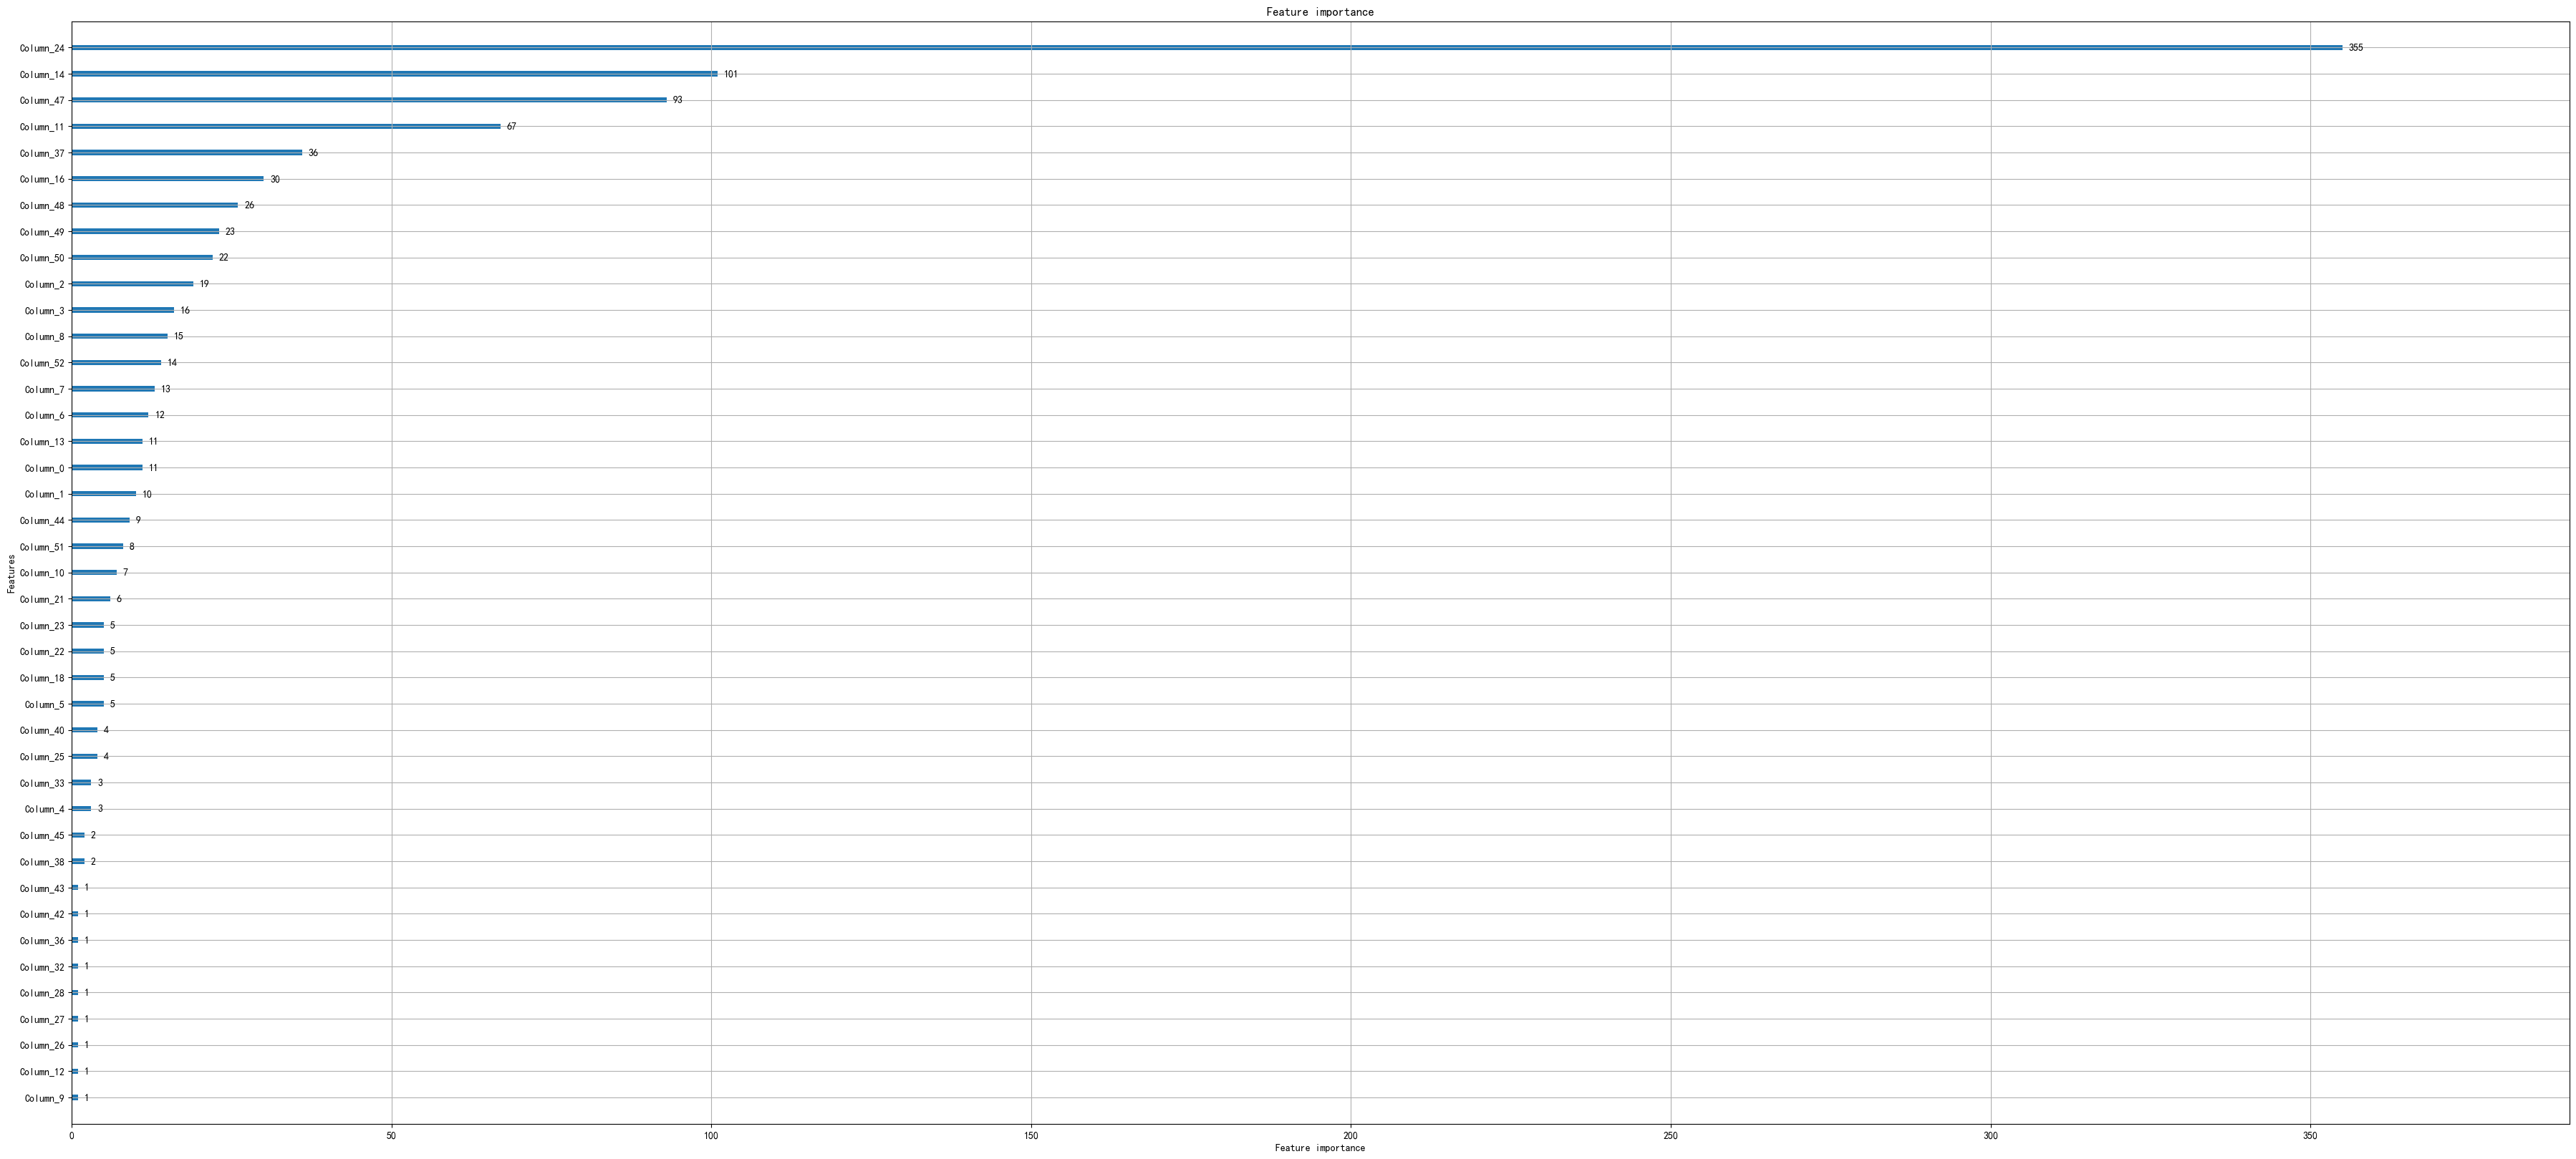

In [ ]:
from lightgbm import plot_importance
drop_split_importance_df = build_importance_df(gbm_drop_uni, train_x_drop_gbm_pd.columns)
drop_gain_importance_df = build_importance_df(gbm_drop_gain, train_x_drop_gain_pd.columns)

print('split-based 删列模型 split importance')
plot_importance(gbm_drop_uni, importance_type='split', figsize=(45, 20), max_num_features=30)
plt.show()
print('split-based 删列模型 gain importance')
plot_importance(gbm_drop_uni, importance_type='gain', figsize=(45, 20), max_num_features=30)
plt.show()

print('gain-based 删列模型 split importance')
plot_importance(gbm_drop_gain, importance_type='split', figsize=(45, 20), max_num_features=30)
plt.show()
print('gain-based 删列模型 gain importance')
plot_importance(gbm_drop_gain, importance_type='gain', figsize=(45, 20), max_num_features=30)
plt.show()

display(drop_split_importance_df.head(20))
display(drop_gain_importance_df.head(20))
selection_compare_df

In [ ]:
print(y_test_drop_uni, gbm_drop_uni.predict(X_test_drop_uni))

3521    12.028
3522    12.108
3523    12.217
3524    12.235
3525    12.244
         ...  
4923     3.744
4924     3.791
4925     4.243
4926     4.285
4927     4.491
Name: 求解时间, Length: 1407, dtype: float64 [13.11420288 13.11420288 13.41484782 ...  0.29811483  0.98141723
  1.26772925]


In [ ]:
len(train_x_drop_xgb_pd.columns)

60